# Component Based Segmentation

In [2]:
!pip install pandas matplotlib seaborn

In [3]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 40.4 MB/s eta 0:00:00


In [4]:
import re
import difflib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import Levenshtein


In [5]:
import os

def get_gt_filename():
    try:
        from google.colab import files
        print("Upload Ground Truth file:")
        uploaded = files.upload()
        return list(uploaded.keys())[0]

    except ImportError:
        default_path = "path/to/your/ground_truth_file.png"  # change this

        if os.path.exists(default_path):
            print(f"Using local file: {default_path}")
            return default_path
        else:
            return input("Enter path to Ground Truth file: ")

gt_filename = get_gt_filename()

Upload Ground Truth file:


Saving ground_truth.md to ground_truth.md


In [6]:
def get_model_files():
    try:
        from google.colab import files
        print("Upload all model output files:")
        uploaded = files.upload()
        model_files = list(uploaded.keys())
        print("Model files:", model_files)
        return model_files

    except ImportError:
        default_paths = ["path/to/model1.md", "path/to/model2.md"]  # change these

        existing_files = [f for f in default_paths if os.path.exists(f)]

        if existing_files:
            print("Using local model files:", existing_files)
            return existing_files
        else:
            paths = input("Enter paths to model files: ")
            return [p.strip() for p in paths.split(",")]

model_files = get_model_files()

Upload all model output files:


Saving chandra_output.md to chandra_output.md
Saving deepseek_ocr_output.md to deepseek_ocr_output.md
Saving deepseek_ocr2_output.md to deepseek_ocr2_output.md
Saving docling_output.md to docling_output.md
Saving doctr_output.md to doctr_output.md
Saving easyocr_output.md to easyocr_output.md
Saving florence2_output.md to florence2_output.md
Saving gemini2.5_output.md to gemini2.5_output.md
Saving GLM_ocr_output.md to GLM_ocr_output.md
Saving haiku_output.md to haiku_output.md
Saving hunyuan_output.md to hunyuan_output.md
Saving landingai_output.md to landingai_output.md
Saving latex_output.md to latex_output.md
Saving lightonocr_output.md to lightonocr_output.md
Saving llamaindex.md to llamaindex.md
Saving llamaparse_output.md to llamaparse_output.md
Saving mistral_output.md to mistral_output.md
Saving nemotron_ocr_output.md to nemotron_ocr_output.md
Saving paddle_ocr_output.md to paddle_ocr_output.md
Saving pdfplumber_output.md to pdfplumber_output.md
Saving Qianfan_ocr_output.md to 

In [7]:
from pathlib import Path

def read_file(filename):
    with open(filename, "r", encoding="utf-8") as f:
        return f.read()

ground_truth = read_file(gt_filename)

model_outputs = {}
for mf in model_files:
    name = Path(mf).stem
    name = re.sub(r'_output$', '', name)
    model_outputs[name] = read_file(mf)

In [8]:
# SEGMENTATION FUNCTION

def segment_markdown(md_text):
    segments = {
        "Header": "",
        "Text": "",
        "Table": "",
        "Numbers": "",
        "Graph": ""
    }

    lines = md_text.split("\n")

    for line in lines:
        stripped = line.strip()

        if stripped.startswith("#"):
            segments["Header"] += line + "\n"

        elif "|" in stripped:
            segments["Table"] += line + "\n"

        elif "figure" in stripped.lower() or "chart" in stripped.lower():
            segments["Graph"] += line + "\n"

        elif re.search(r"\d+\.?\d*", stripped):
            segments["Numbers"] += line + "\n"

        else:
            segments["Text"] += line + "\n"

    return segments



In [9]:
# METRICS (Levenshtein version)

def calculate_cer(reference, hypothesis):
    """
    True Character Error Rate (CER)
    using Levenshtein distance.
    """
    ref = str(reference).strip()
    hyp = str(hypothesis).strip()

    if not ref:
        return 1.0 if hyp else 0.0

    distance = Levenshtein.distance(ref, hyp)
    return distance / len(ref)


def numeric_f1(gt_text, pred_text):
    gt_nums = re.findall(r"\d+\.?\d*", gt_text)
    pred_nums = re.findall(r"\d+\.?\d*", pred_text)

    if not gt_nums and not pred_nums:
        return 1.0
    if not gt_nums:
        return 0.0

    gt_set = set(gt_nums)
    pred_set = set(pred_nums)

    true_positive = len(gt_set & pred_set)
    precision = true_positive / len(pred_set) if pred_set else 0
    recall = true_positive / len(gt_set)

    if precision + recall == 0:
        return 0

    return 2 * precision * recall / (precision + recall)


def presence_score(gt_component, pred_component):
    if gt_component and pred_component:
        return 1.0
    if gt_component and not pred_component:
        return 0.0
    if not gt_component and pred_component:
        return 0.0
    return 1.0


def table_structure_score(gt_table, pred_table):
    gt_rows = gt_table.count("\n")
    pred_rows = pred_table.count("\n")

    if gt_rows == 0 and pred_rows == 0:
        return 1.0
    if gt_rows == 0:
        return 0.0

    score = 1 - abs(gt_rows - pred_rows) / max(gt_rows, 1)
    return max(0, score)

In [10]:
# EVALUATION


def cer_to_accuracy(reference, prediction):
    """
    Converts CER to accuracy and clips result to [0, 1].
    """
    cer = calculate_cer(reference, prediction)
    return max(0.0, 1.0 - cer)


results = []

gt_segments = segment_markdown(ground_truth)

for model_name, model_text in model_outputs.items():
    pred_segments = segment_markdown(model_text)

    # Header
    header_score = cer_to_accuracy(gt_segments["Header"], pred_segments["Header"])

    # Text
    text_score = cer_to_accuracy(gt_segments["Text"], pred_segments["Text"])

    # Table (content + structure)
    table_content = cer_to_accuracy(gt_segments["Table"], pred_segments["Table"])

    table_structure = table_structure_score(gt_segments["Table"], pred_segments["Table"])

    table_score = 0.6 * table_content + 0.4 * table_structure

    # Numbers (F1)
    numbers_score = numeric_f1(gt_segments["Numbers"], pred_segments["Numbers"])

    # Graph (presence * content accuracy)
    if not gt_segments["Graph"] and not pred_segments["Graph"]:
        graph_score = 1.0
    elif not gt_segments["Graph"] and pred_segments["Graph"]:
        graph_score = 0.0
    else:
        graph_presence = presence_score(gt_segments["Graph"], pred_segments["Graph"])
        graph_content = cer_to_accuracy(gt_segments["Graph"], pred_segments["Graph"])
        graph_score = graph_presence * graph_content

    results.append({
        "Model": model_name,
        "Header": header_score,
        "Text": text_score,
        "Table": table_score,
        "Numbers": numbers_score,
        "Graph": graph_score
    })


df = pd.DataFrame(results).set_index("Model")
df


,Header,Text,Table,Numbers,Graph
Model,,,,,
chandra,0.748543,0.832756,0.669125,0.901042,0.785376
deepseek_ocr,0.748426,0.826138,0.000000,0.493188,0.785376
deepseek_ocr2,0.679762,0.786031,0.000000,0.491758,0.826933
docling,0.666123,0.713843,0.321081,0.834606,0.933193
doctr,0.078107,0.000000,0.000000,0.391351,0.139400
easyocr,0.078107,0.368871,0.107492,0.441362,0.177801
florence2,0.078107,0.044351,0.039532,0.161538,0.000000
gemini2.5,0.078107,0.054887,0.000000,0.480519,0.149395
GLM_ocr,0.078806,0.771839,0.189730,0.496680,0.803261


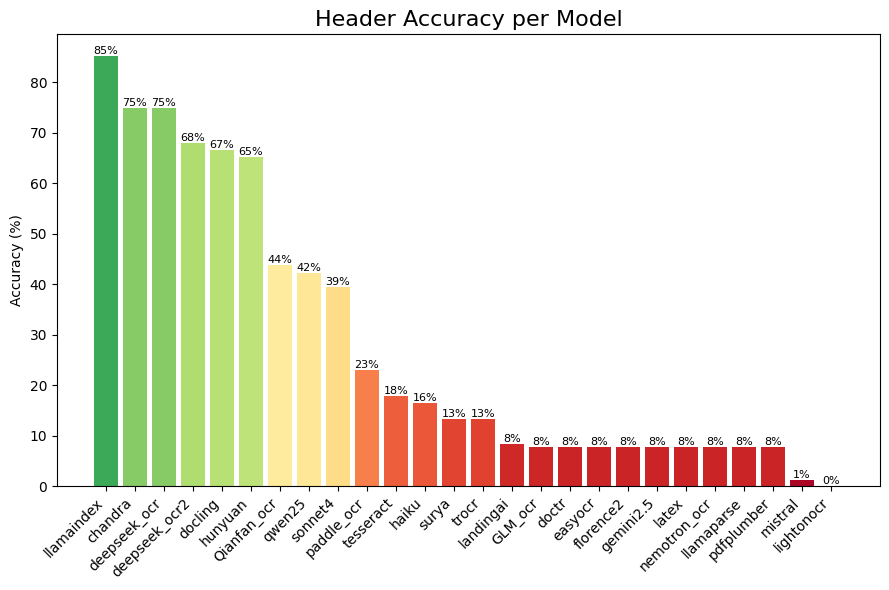

In [12]:
# HEADER ACCURACY VISUALIZATION

import matplotlib.pyplot as plt
import numpy as np

component = "Header"

sorted_df = df.sort_values(component, ascending=False)
values = sorted_df[component] * 100

colors = plt.cm.RdYlGn(values / 100)

plt.figure(figsize=(9,6))
bars = plt.bar(sorted_df.index, values, color=colors)

plt.title("Header Accuracy per Model", fontsize=16)
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.0f}%",
             ha="center",
             va="bottom",
             fontsize=8)

plt.tight_layout()
plt.show()


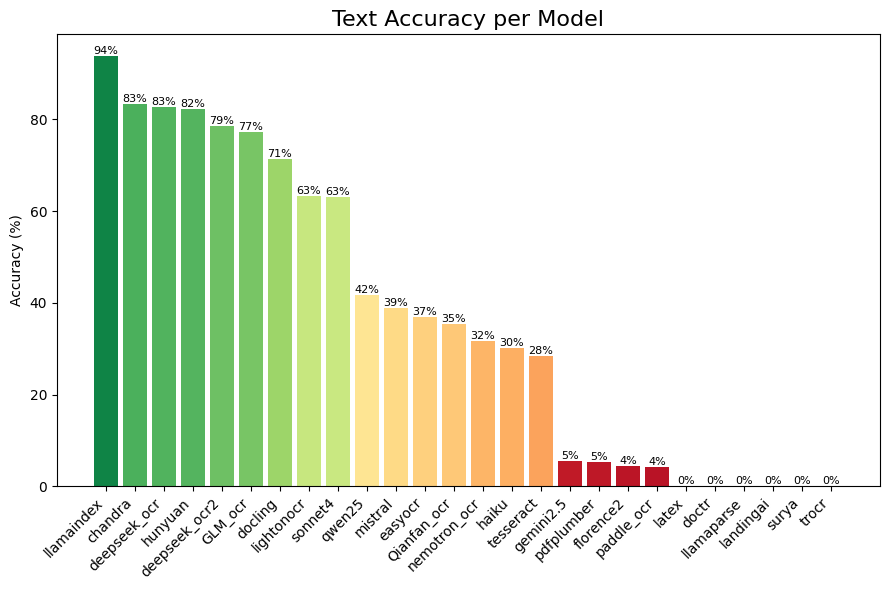

In [13]:
# TEXT ACCURACY VISUALIZATION
component = "Text"

sorted_df = df.sort_values(component, ascending=False)
values = sorted_df[component] * 100

colors = plt.cm.RdYlGn(values / 100)

plt.figure(figsize=(9,6))
bars = plt.bar(sorted_df.index, values, color=colors)

plt.title("Text Accuracy per Model", fontsize=16)
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.0f}%",
             ha="center",
             va="bottom",
             fontsize=8)

plt.tight_layout()
plt.show()


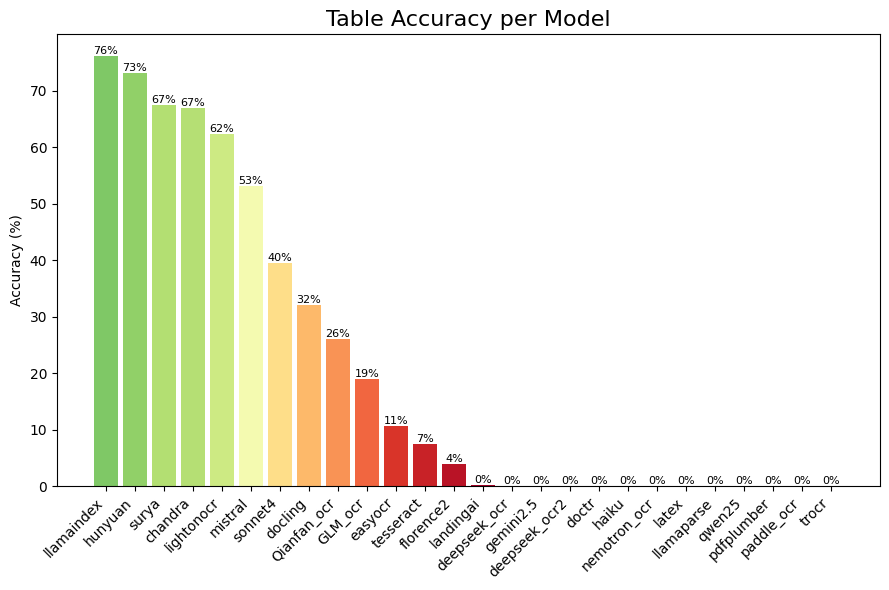

In [14]:
# TABLE ACCURACY VISUALIZATION
component = "Table"

sorted_df = df.sort_values(component, ascending=False)
values = sorted_df[component] * 100

colors = plt.cm.RdYlGn(values / 100)

plt.figure(figsize=(9,6))
bars = plt.bar(sorted_df.index, values, color=colors)

plt.title("Table Accuracy per Model", fontsize=16)
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.0f}%",
             ha="center",
             va="bottom",
             fontsize=8)

plt.tight_layout()
plt.show()


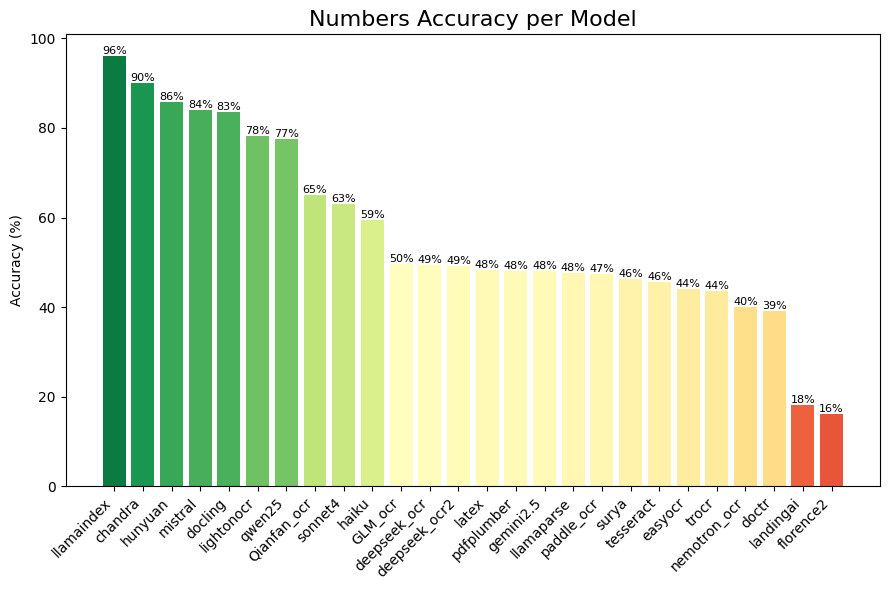

In [15]:
# NUMBERS ACCURACY VISUALIZATION

component = "Numbers"

sorted_df = df.sort_values(component, ascending=False)
values = sorted_df[component] * 100

colors = plt.cm.RdYlGn(values / 100)

plt.figure(figsize=(9,6))
bars = plt.bar(sorted_df.index, values, color=colors)

plt.title("Numbers Accuracy per Model", fontsize=16)
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.0f}%",
             ha="center",
             va="bottom",
             fontsize=8)

plt.tight_layout()
plt.show()


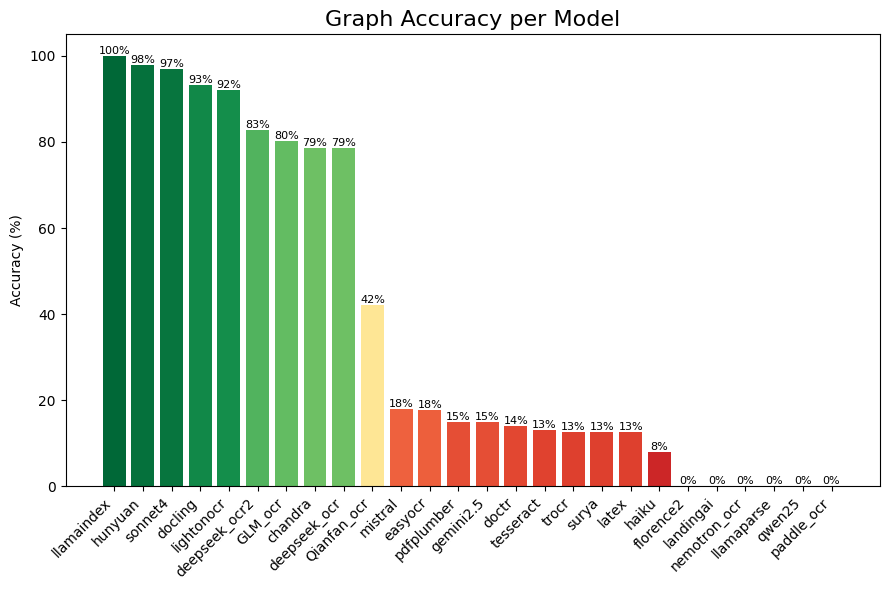

In [16]:
# GRAPH ACCURACY VISUALIZATION

component = "Graph"

sorted_df = df.sort_values(component, ascending=False)
values = sorted_df[component] * 100

colors = plt.cm.RdYlGn(values / 100)

plt.figure(figsize=(9,6))
bars = plt.bar(sorted_df.index, values, color=colors)

plt.title("Graph Accuracy per Model", fontsize=16)
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.0f}%",
             ha="center",
             va="bottom",
             fontsize=8)

plt.tight_layout()
plt.show()
